# Regularized Logistic Regression from Scratch
We implements logistic regression with L2 regularization, grid search, and 5-fold cross-validation using the Breast Cancer dataset.

In [1]:
# Import libraries
# sklearn.datasets: ONLY for loading dataset
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [2]:
# Load dataset 
X, y = load_breast_cancer(return_X_y=True)

df = pd.DataFrame(X)
df['target'] = y
print("Preview of dataset:")
print(df.head())

print("\nDataset shape:", df.shape)

Preview of dataset:
       0      1       2       3        4        5       6        7       8  \
0  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001  0.14710  0.2419   
1  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869  0.07017  0.1812   
2  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974  0.12790  0.2069   
3  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414  0.10520  0.2597   
4  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980  0.10430  0.1809   

         9  ...     21      22      23      24      25      26      27  \
0  0.07871  ...  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.05667  ...  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.05999  ...  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.09744  ...  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.05883  ...  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       28       29  target  
0  0.4601  0.11890       0  
1  0.275

In [3]:
# Normalize features 
X = (X - X.mean(axis=0)) / X.std(axis=0)

X = np.c_[np.ones(X.shape[0]), X]

In [4]:
# Sigmoid function TO Converts any number → probability (0 to 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
# Cost function with L2 regularization
def compute_cost(X, y, theta, lam):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-5  # prevent log(0)

    cost = (-1/m) * np.sum(y*np.log(h+epsilon) + (1-y)*np.log(1-h+epsilon))
    reg = (lam/(2*m)) * np.sum(theta[1:]**2)

    return cost + reg

In [6]:
# Gradient Descent to optimize parameters & Repeats many times to minimize error
def gradient_descent(X, y, theta, lr, lam, iterations):
    m = len(y)

    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))

        # Apply regularization (skip bias)
        gradient[1:] += (lam/m) * theta[1:]

        theta -= lr * gradient

    return theta

In [7]:
# Predict class labels
def predict(X, theta):
    probs = sigmoid(X @ theta)
    return (probs >= 0.5).astype(int)

In [8]:
# Compute confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))    #TP → correct positive
    TN = np.sum((y_true == 0) & (y_pred == 0))   #TN → correct negative
    FP = np.sum((y_true == 0) & (y_pred == 1))   #FP → wrong positive
    FN = np.sum((y_true == 1) & (y_pred == 0))   #FN → wrong negative
    return TP, TN, FP, FN

In [9]:
# Split data into K folds
def k_fold_split(X, y, k=5):
    indices = np.arange(len(y))
    np.random.shuffle(indices)
    return np.array_split(indices, k)

In [10]:
# Grid search with 5-fold cross-validation
def grid_search(X, y, lambdas, k=5):
    folds = k_fold_split(X, y, k)
    best_lambda = None
    best_score = -1

    for lam in lambdas:
        scores = []

        for i in range(k):
            val_idx = folds[i]
            train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

            X_train, y_train = X[train_idx], y[train_idx]
            X_val, y_val = X[val_idx], y[val_idx]

            theta = np.zeros(X.shape[1])
            theta = gradient_descent(X_train, y_train, theta, lr=0.01, lam=lam, iterations=1000)

            preds = predict(X_val, theta)
            accuracy = np.mean(preds == y_val)
            scores.append(accuracy)

        avg_score = np.mean(scores)
        print(f"Lambda: {lam}, CV Accuracy: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_lambda = lam

    return best_lambda, best_score

In [11]:
# Try different regularization values
lambdas = [0.01, 0.1, 1, 10]

best_lambda, best_score = grid_search(X, y, lambdas)

print("\nBest Lambda:", best_lambda)
print("Best CV Accuracy:", best_score)

Lambda: 0.01, CV Accuracy: 0.9737
Lambda: 0.1, CV Accuracy: 0.9737
Lambda: 1, CV Accuracy: 0.9737
Lambda: 10, CV Accuracy: 0.9736

Best Lambda: 0.01
Best CV Accuracy: 0.9736531594472908


In [12]:
# Train final model using best lambda
theta = np.zeros(X.shape[1])
theta = gradient_descent(X, y, theta, lr=0.01, lam=best_lambda, iterations=1000)

In [13]:
# Evaluate using confusion matrix
preds = predict(X, theta)
TP, TN, FP, FN = confusion_matrix(y, preds)

print("\nConfusion Matrix:")
print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

accuracy = (TP + TN) / len(y)
print("Accuracy:", accuracy)


Confusion Matrix:
TP: 355 TN: 204 FP: 8 FN: 2
Accuracy: 0.9824253075571178


Matplotlib is building the font cache; this may take a moment.


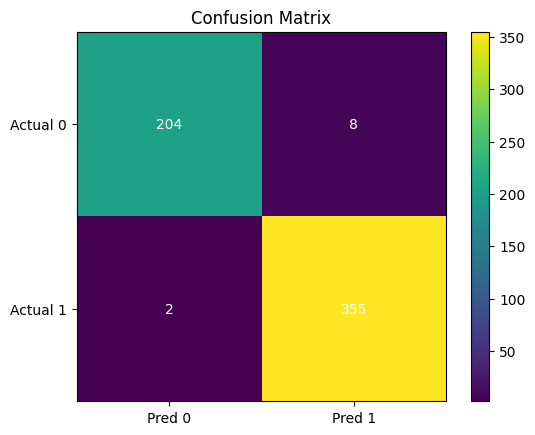

In [14]:
import matplotlib.pyplot as plt

# Create confusion matrix values
cm = np.array([[TN, FP],
               [FN, TP]])

# Plot
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white")
        
plt.savefig("confusion_matrix.png")

plt.show()